# MultiHop-RAG (COLM 2024) — multi-doc reasoning

**Paper:** [Tang & Yang, arXiv:2401.15391](https://arxiv.org/abs/2401.15391)  
**Dataset:** HF `yixuantt/MultiHopRAG` — 2,556 queries, evidence across 2–4 news docs.

This harness builds a **closed-world mini subset** (gold evidence articles + distractors), runs local methods, and applies the same **dual scoreboard** as the Hotpot autopsy so GraphRAG isn’t punished for prose.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, Image, display
from dotenv import load_dotenv

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
load_dotenv(ROOT / ".env")

from rag_benchmark import build_multihop_rag_subset
from rag_benchmark.charts import METHOD_LABELS, print_leaderboard
from rag_benchmark.metric_autopsy import (
    enrich_accuracy,
    method_metric_profile,
    question_catalog,
    scenario_dual_leaderboard,
    write_autopsy_artifacts,
)

N_PER_TYPE = 3
RUN_BENCHMARK = False  # True → python scripts/run_multihop_benchmark.py
RESULTS = ROOT / "results_multihop"
RESULTS.mkdir(parents=True, exist_ok=True)

built = build_multihop_rag_subset(project_root=ROOT, n_per_type=N_PER_TYPE)
display(Markdown("### Subset meta"))
display(pd.Series(built["meta"]).to_frame("value"))


### Subset meta

,value
dataset,MultiHop-RAG
paper,"Tang & Yang, COLM 2024"
citation,https://arxiv.org/abs/2401.15391
n_questions,9
n_documents,30
n_gold_docs,22
n_distractors,8
type_counts,"{'inference_query': 3, 'comparison_query': 3, ..."
corpus_dir,/Users/jimmyscray/Code/rag-benchmark/data/corp...
qa_path,/Users/jimmyscray/Code/rag-benchmark/data/qa/m...


## Question catalog


In [2]:
catalog = pd.read_csv(ROOT / "results" / "multihop_question_catalog.csv")
display(catalog)
qa = pd.read_json(built["qa_path"])
for i, q in qa.iterrows():
    print(f"Q{i+1} [{q.multihop_type}] {q.id}")
    print(f"  {q.question}")
    print(f"  Gold: {q.expected_answer}\n")


,label,question_id,question_type,query_type,question,gold_answer,n_evidence
0,Q1,mh-inf-000-meta,inference_query,hybrid,"What company, recently scrutinized by European...",Meta,3
1,Q2,mh-inf-001-meta,inference_query,hybrid,"Which company, featured in TechCrunch articles...",Meta,3
2,Q3,mh-inf-002-uber,inference_query,hybrid,"What company, according to TechCrunch, experie...",Uber,3
3,Q4,mh-com-003-no,comparison_query,local,Does 'The Independent - Life and Style' articl...,no,3
4,Q5,mh-com-004-no,comparison_query,local,Did the TechCrunch article indicate that Googl...,no,3
5,Q6,mh-com-005-no,comparison_query,local,Does 'The Verge' article suggest that Sam Bank...,no,3
6,Q7,mh-tem-006-no,temporal_query,hybrid,Was there no change in the portrayal of Google...,no,3
7,Q8,mh-tem-007-no,temporal_query,hybrid,Has the advice provided by Sporting News to be...,no,3
8,Q9,mh-tem-008-no,temporal_query,hybrid,Was there inconsistency in Jada Pinkett Smith'...,no,3


Q1 [inference_query] mh-inf-000-meta
  What company, recently scrutinized by European consumer groups for its ad-free subscription model's GDPR compliance and by EU regulators for content moderation during the Israel-Hamas war, also faces allegations of bias in suppressing Palestinian voices, as reported by TechCrunch?
  Gold: Meta

Q2 [inference_query] mh-inf-001-meta
  Which company, featured in TechCrunch articles, is both seeking to involve parents in the oversight of teens' app usage and addressing content moderation challenges related to livestreaming during the Israel-Hamas war, while also facing criticism for alleged moderation biases affecting Palestinian voices?
  Gold: Meta

Q3 [inference_query] mh-inf-002-uber
  What company, according to TechCrunch, experienced a 38% decrease in reported sexual assault rates between its first and second safety reports, faces criticism for inadequate background checks aimed at quick driver sign-up, and reported $394 million in operating inc

## Results + dual scoreboard

If `RUN_BENCHMARK` is False, loads `results_multihop/`. Generative score is the primary multi-hop leaderboard.


### Dual scoreboard by MultiHop-RAG question type

,scenario,generative_winner,generative_score,extractive_winner,extractive_score,composite_winner,composite_score,ranking_flips
0,comparison_query,Hybrid (vec+graph local),0.633,FrontierRAG (adaptive+CRAG),0.000,Hybrid (vec+graph local),0.317,False
1,inference_query,Hybrid (vec+graph local),0.633,Hybrid (vec+graph local),0.023,Hybrid (vec+graph local),0.328,False
2,temporal_query,FrontierRAG (adaptive+CRAG),0.533,FrontierRAG (adaptive+CRAG),0.000,FrontierRAG (adaptive+CRAG),0.267,False


### Method profile (generative-first)

,label,generative,extractive,composite,llm_judge,contains,token_f1,exact_match
1,Hybrid (vec+graph local),0.533,0.008,0.270,0.178,0.889,0.015,0.0
2,Vector + rerank,0.500,0.004,0.252,0.111,0.889,0.008,0.0
3,Semantic (vector),0.489,0.005,0.247,0.200,0.778,0.011,0.0
0,FrontierRAG (adaptive+CRAG),0.444,0.004,0.224,0.111,0.778,0.008,0.0


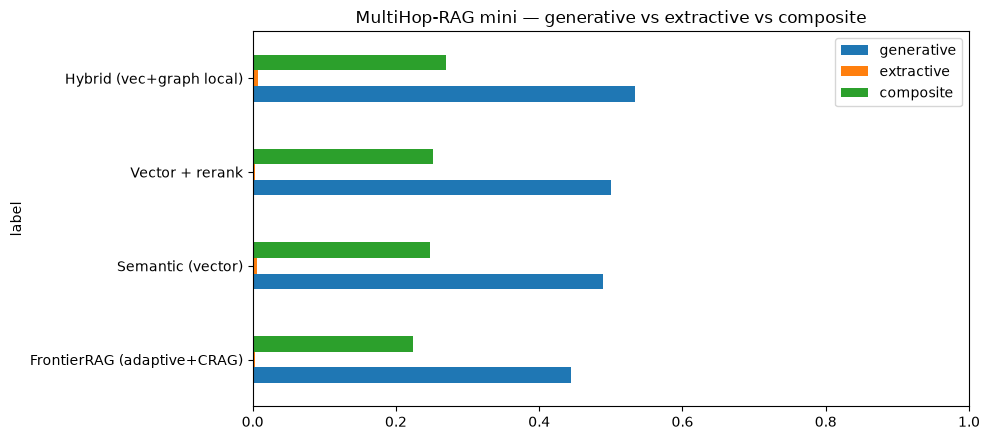


=== BENCHMARK LEADERBOARD ===
                      label  mean_composite_score  mean_llm_judge  mean_token_f1  total_tokens  tokens_per_query  index_seconds  mean_query_latency_seconds  total_elapsed_seconds
          Semantic (vector)                 0.247           0.200          0.011         47849          5316.556          0.148                      12.264                132.604
   Hybrid (vec+graph local)                 0.270           0.178          0.015         53037          5893.000          0.047                      21.513                210.456
            Vector + rerank                 0.252           0.111          0.008         47790          5310.000          0.046                      11.161                119.258
FrontierRAG (adaptive+CRAG)                 0.224           0.111          0.008         69076          7675.111          0.124                      16.006                161.149

=== QUALITY BY SCENARIO ===
query_type                   hybrid  local
la

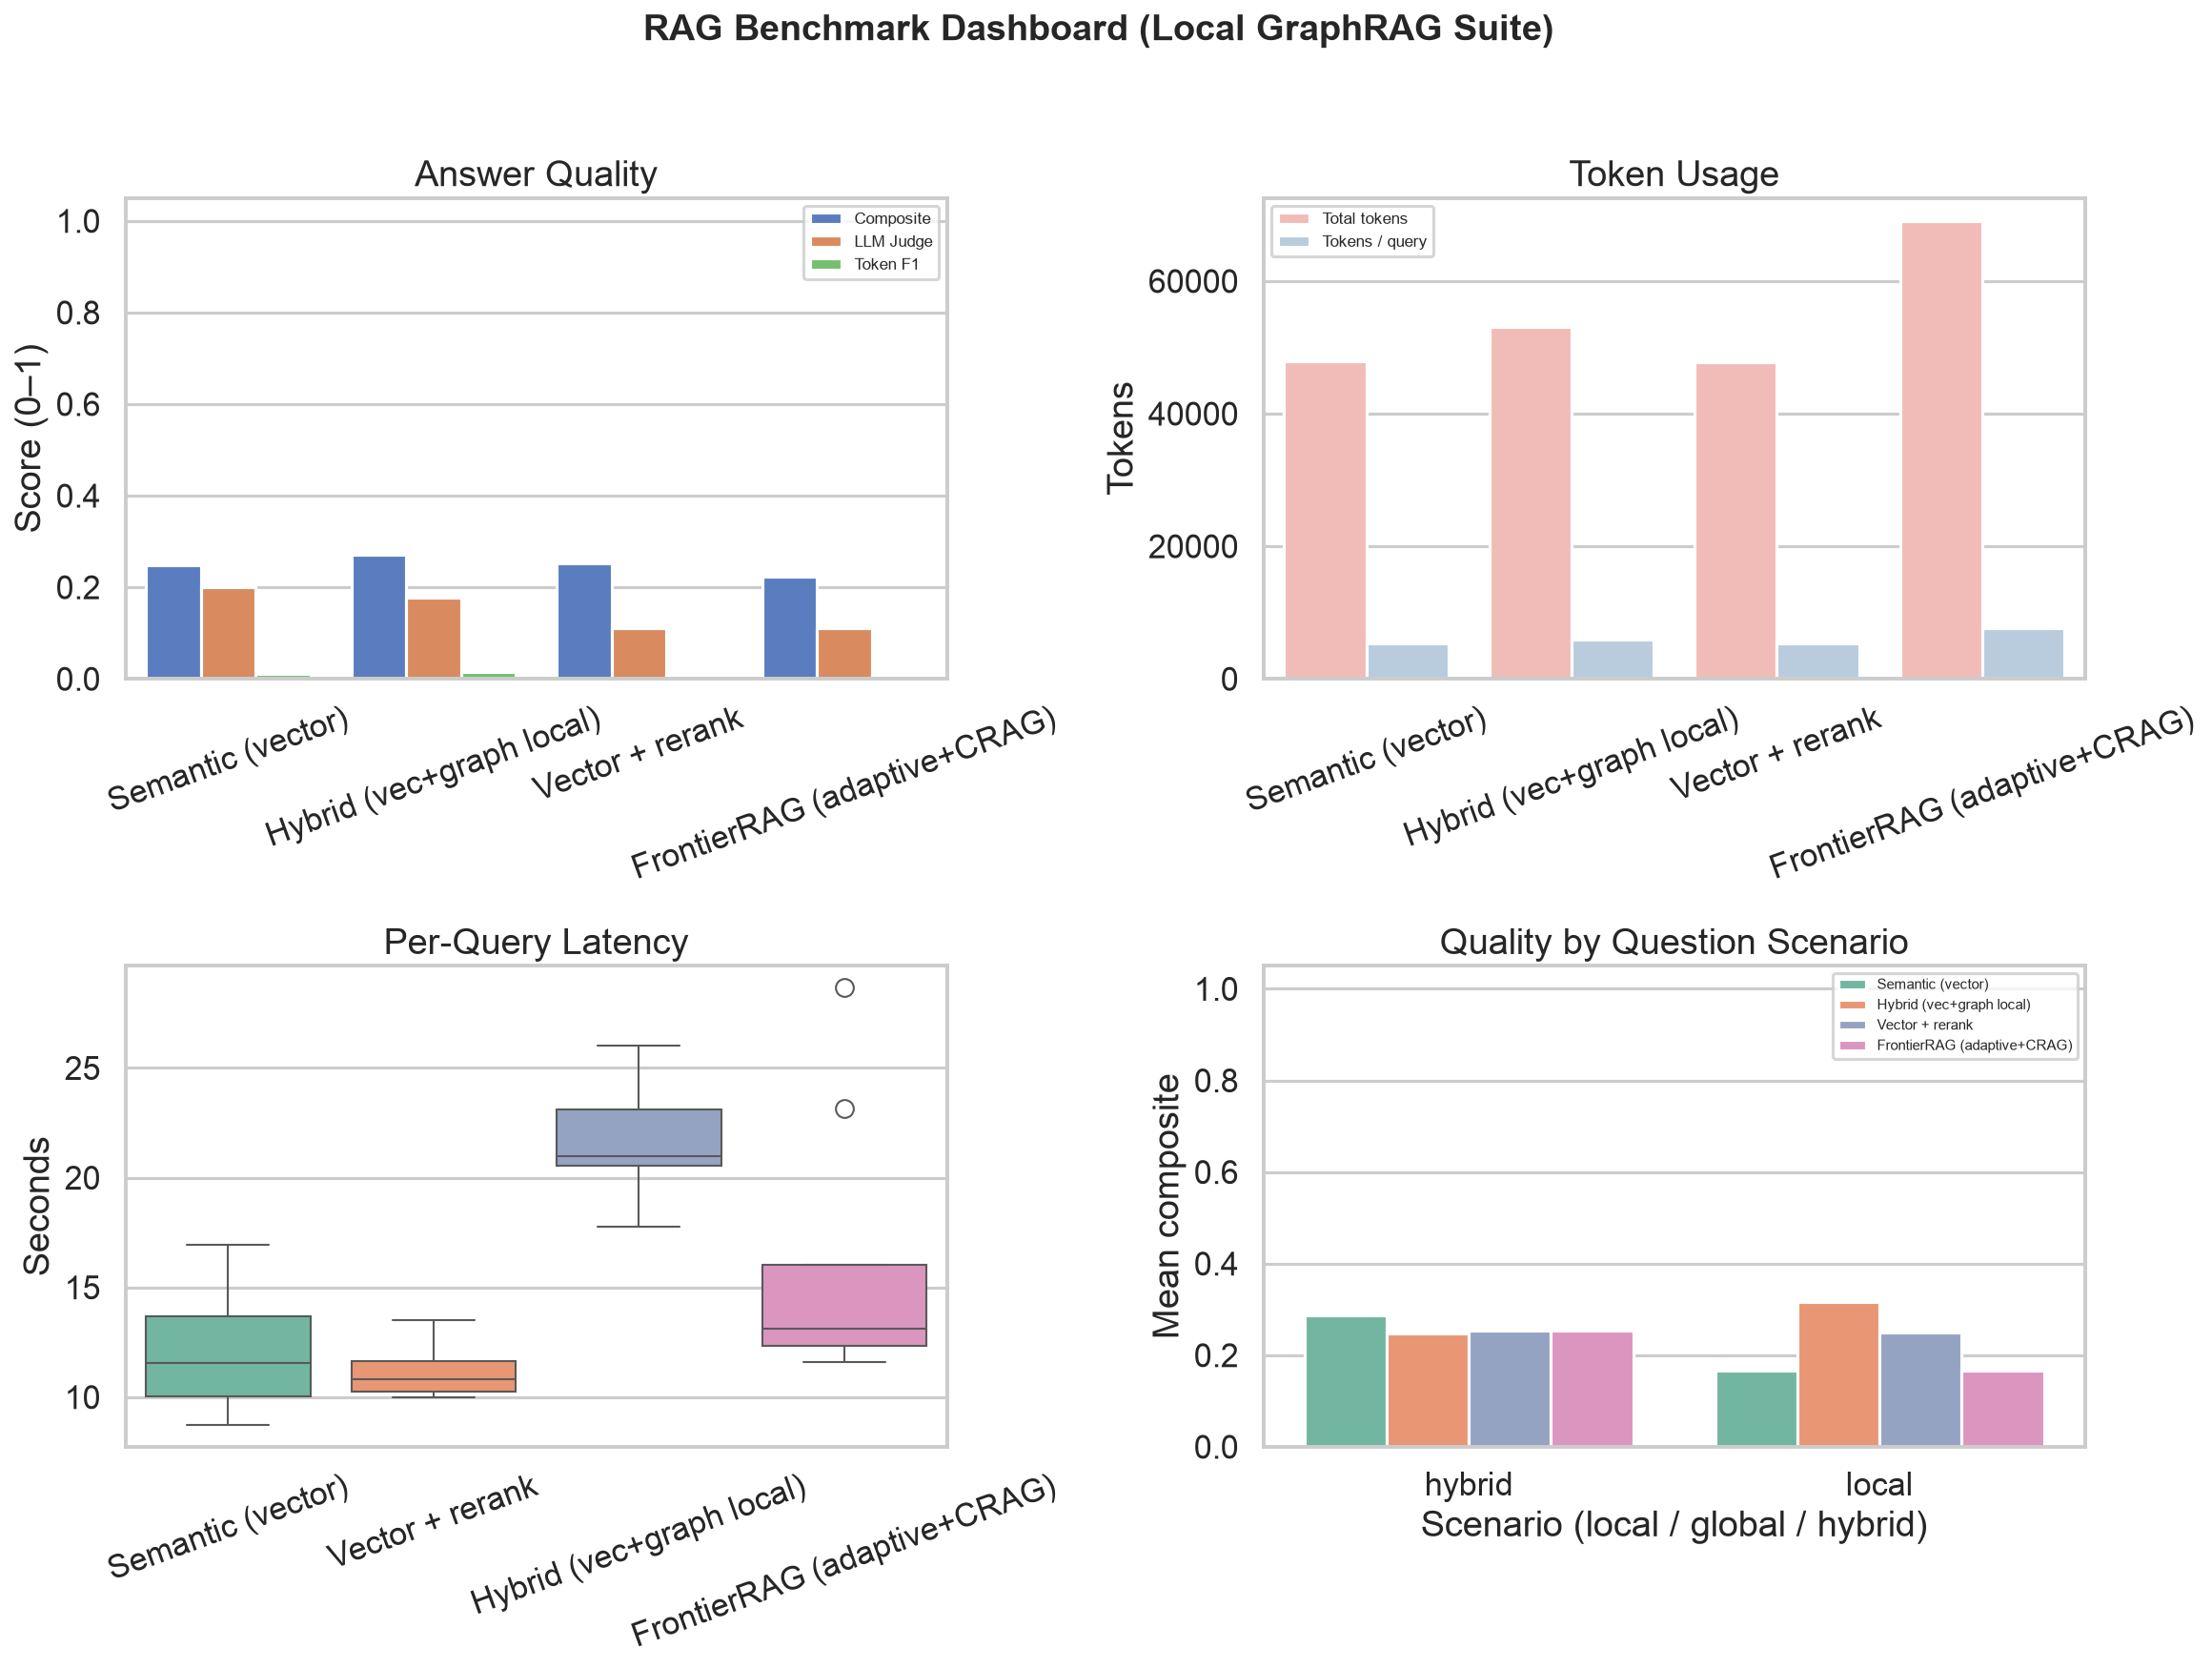

In [3]:
assert (RESULTS / "accuracy_results.csv").exists(), (
    "Run: PYTHONPATH=src python scripts/run_multihop_benchmark.py"
)
acc = enrich_accuracy(pd.read_csv(RESULTS / "accuracy_results.csv"))
write_autopsy_artifacts(
    results_dir=RESULTS,
    qa_path=Path(built["qa_path"]),
    type_key="multihop_type",
    scenario_col="multihop_type",
)

display(Markdown("### Dual scoreboard by MultiHop-RAG question type"))
display(scenario_dual_leaderboard(acc, scenario_col="multihop_type"))

display(Markdown("### Method profile (generative-first)"))
display(method_metric_profile(acc)[
    ["label", "generative", "extractive", "composite", "llm_judge", "contains", "token_f1", "exact_match"]
].round(3))

profile = method_metric_profile(acc).set_index("label")
fig, ax = plt.subplots(figsize=(10, 4.5))
profile[["generative", "extractive", "composite"]].sort_values("generative").plot(kind="barh", ax=ax)
ax.set_xlim(0, 1)
ax.set_title("MultiHop-RAG mini — generative vs extractive vs composite")
plt.tight_layout()
plt.show()

print_leaderboard(RESULTS)
if (RESULTS / "benchmark_dashboard.png").exists():
    display(Image(filename=str(RESULTS / "benchmark_dashboard.png")))


## How to read this vs Hotpot / GraphRAG-Bench

| Suite | What it stresses | Prefer |
|-------|------------------|--------|
| HotpotQA | Wikipedia bridge/comparison spans | Extractive for EM papers; generative for UX |
| **MultiHop-RAG** | News multi-doc inference / temporal / comparison | **Generative** + retrieval recall |
| GraphRAG-Bench | Fact → creative task ladder | Generative on summarize/creative |

If composite says “vector wins multi-hop” but generative says “graph/hybrid wins”, trust generative for GraphRAG product decisions.
